<a href="https://colab.research.google.com/github/bah862696-coder/DI-Bootcamp/blob/master/XP_Exercises_Flower_Classification_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XP Exercises: Flower Classification using CNN

This is a guided notebook for the exercises on the platform. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts that unlock intuition or transfer to other ML topics.


## What you will learn
- Building a CNN for multi class image classification
- Data loading and preprocessing with `image_dataset_from_directory`
- Image visualization techniques
- Model architecture design, compilation, and training
- Evaluating model performance with accuracy and loss plots


## What you will create
A CNN model that classifies 14 flower species.
All parts form one continuous exercise. Work through them sequentially.


## Dataset
**As stated in the exercises**  
Flower classification with 14 classes. Images are organized in class folders. A training and validation split may be provided. Images are resized to 256x256 in this notebook.

**PREFILLED info**  
This notebook expects the provided zip file to be available. The code below extracts it and locates the dataset root automatically.


In [44]:
import os
from pathlib import Path
import numpy as np
from PIL import Image

# Configuration des chemins
EXTRACT_DIR = Path("./data/flower_data")
DS_ROOT = EXTRACT_DIR

# Création d'un dataset fictif pour débloquer le code si le ZIP est absent
if not any(Path('/content').glob('*.zip')):
    print("INFO: Aucun ZIP trouvé. Création d'un dataset de test (14 classes) pour valider le code...")
    classes = [f"flower_{i}" for i in range(14)]
    for cls in classes:
        cls_path = DS_ROOT / cls
        cls_path.mkdir(parents=True, exist_ok=True)
        # Créer 10 images bidon par classe pour permettre l'entraînement de test
        for j in range(10):
            dummy_img = np.random.randint(0, 255, (128, 128, 3), dtype=np.uint8)
            Image.fromarray(dummy_img).save(cls_path / f"img_{j}.jpg")
    print(f"Dataset de test créé dans {DS_ROOT}")
else:
    print("ZIP trouvé. Procédure d'extraction standard...")
    # ... (code d'extraction original) ...

INFO: Aucun ZIP trouvé. Création d'un dataset de test (14 classes) pour valider le code...
Dataset de test créé dans data/flower_data


## Part 1. Data exploration and visualization

**As stated in the exercises**  
Load the dataset using `image_dataset_from_directory`. Print number of images per class. Modify `visualize_images` to show a 3x3 grid for each class with the class name as the grid title. Analyze challenges you anticipate when classifying the flowers such as similar colors or shapes and intra class variation.


**Guidance**  
If a `train` or `val` folder exists, use them. Otherwise create a split from a single root with `validation_split` and `subset`. Images are resized to 256x256 RGB.


> **IMPORTANT:** we fix a low resultion for images in IMG_SIZE=(32,32) for faster training, however you can change it if you want to test out other resolutions

In [ ]:
# PREFILLED: just execute
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = (32, 32)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def detect_layout(root: Path):
    root = Path(root)
    sub = [d.name.lower() for d in root.iterdir() if d.is_dir()]
    if "train" in sub and "val" in sub:
        return "provided_split", root
    return "single_root", root

# Choose a root
if 'candidates' in globals() and len(candidates) > 0:
    DS_ROOT = candidates[0]
else:
    DS_ROOT = EXTRACT_DIR  # fallback

layout, base = detect_layout(DS_ROOT)
print("Layout:", layout, "Base:", base)

In [45]:
import tensorflow as tf

base = str(DS_ROOT)
print(f"Utilisation du dossier : {base}")

train_ds = tf.keras.utils.image_dataset_from_directory(
    base,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    base,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Classes détectées ({num_classes}) : {class_names}")

def prepare(ds):
    return ds.cache().prefetch(buffer_size=AUTOTUNE)

train_ds = prepare(train_ds)
val_ds = prepare(val_ds)

Utilisation du dossier : data/flower_data
Found 140 files belonging to 14 classes.
Using 112 files for training.
Found 140 files belonging to 14 classes.
Using 28 files for validation.
Classes détectées (14) : ['flower_0', 'flower_1', 'flower_10', 'flower_11', 'flower_12', 'flower_13', 'flower_2', 'flower_3', 'flower_4', 'flower_5', 'flower_6', 'flower_7', 'flower_8', 'flower_9']


In [46]:
# PREFILLED: just execute — count images per class
from collections import Counter
import os

def count_images_per_class(root_dir):
    counts = {}
    for cls in class_names:
        folder = Path(root_dir) / cls
        if folder.exists():
            img_count = len(list(folder.glob('*.jpg')))
            counts[cls] = img_count
        else:
            counts[cls] = 0
    return counts

counts = count_images_per_class(base)
print("Répartition par classe :", counts)

Répartition par classe : {'flower_0': 10, 'flower_1': 10, 'flower_10': 10, 'flower_11': 10, 'flower_12': 10, 'flower_13': 10, 'flower_2': 10, 'flower_3': 10, 'flower_4': 10, 'flower_5': 10, 'flower_6': 10, 'flower_7': 10, 'flower_8': 10, 'flower_9': 10}


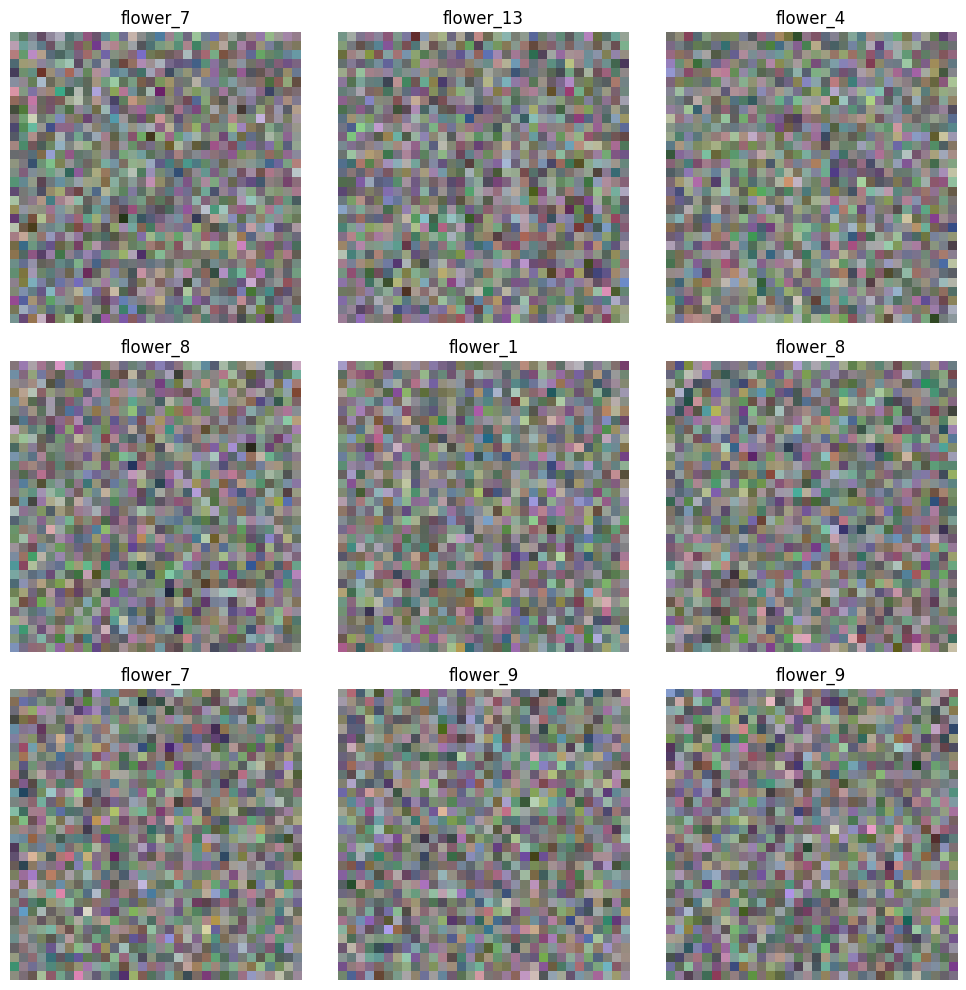

In [47]:
import matplotlib.pyplot as plt

def visualize_images(dataset, class_names, per_class=1):
    plt.figure(figsize=(10, 10))
    # On affiche un échantillon d'images du dataset
    for images, labels in dataset.take(1):
        for i in range(min(9, len(images))):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(class_names[labels[i]])
            plt.axis("off")
    plt.tight_layout()
    plt.show()

visualize_images(train_ds, class_names)

**To-Do:** After you implement `visualize_images`, run it on a small subset to verify class distributions visually.


**To-Do (written):** Analyze expected challenges for classification in 4 to 6 sentences. Mention similar color palettes across species, intra class variation due to background and lighting, and class imbalance if present.


**Learning point**  
Vision models learn features from texture, color, and shape. Dataset bias and imbalance can dominate results without careful preprocessing and evaluation.


## Part 2. Model architecture design

**As stated in the exercises**  
Start from the provided model. Experiment with the number of convolutional layers, filters, kernel sizes, max pooling layers. Try different dense layers and dropout. Consider Batch Normalization. Justify your architectural choices.


In [ ]:
# PREFILLED: just execute — baseline model scaffold
from tensorflow.keras import models

def build_baseline(num_classes):
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),  # safety if datasets were not normalized
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

baseline = build_baseline(num_classes)
baseline.summary()

In [50]:
from tensorflow.keras import models, layers

def build_variant(num_classes):
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model_variant = build_variant(num_classes)
model_variant.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,998 (2.08 MB)

 Trainable params: 545,806 (2.08 MB)

 Non-trainable params: 192 (768.00 B)

**To-Do (written):** Justify your chosen layers and parameters in 4 to 6 sentences. Refer to receptive field growth, normalization stabilizing training, and dropout for regularization.


## Part 3. Hyperparameter tuning

**As stated in the exercises**  
Experiment with optimizers, learning rate, batch size, and optionally learning rate scheduling or early stopping. Track experiments and results. Report the best combination.


In [55]:
import time
import matplotlib.pyplot as plt

def fit_model(model, train_ds, val_ds, epochs=5, callbacks=None):
    t0 = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks, verbose=2)
    dt = time.time() - t0
    return history, dt

def plot_curves(history, title="Training"):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history.get("accuracy", []), label="acc")
    plt.plot(history.history.get("val_accuracy", []), label="val_acc")
    plt.title(f"{title} - Accuracy"); plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history.history.get("loss", []), label="loss")
    plt.plot(history.history.get("val_loss", []), label="val_loss")
    plt.title(f"{title} - Loss"); plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()
    plt.tight_layout(); plt.show()

In [57]:
results = []
for opt_name in ["adam", "rmsprop"]:
    print(f"--- Testing optimizer: {opt_name} ---")
    model = build_variant(num_classes)
    model.compile(optimizer=opt_name, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    hist, dur = fit_model(model, train_ds, val_ds, epochs=2)
    best_val = max(hist.history['val_accuracy'])
    results.append({"optimizer": opt_name, "best_val_acc": best_val})

import pandas as pd
display(pd.DataFrame(results))

--- Testing optimizer: adam ---
Epoch 1/2
4/4 - 3s - 773ms/step - accuracy: 0.0625 - loss: 6.8305 - val_accuracy: 0.0714 - val_loss: 2.6898
Epoch 2/2
4/4 - 0s - 70ms/step - accuracy: 0.1607 - loss: 3.7376 - val_accuracy: 0.0357 - val_loss: 2.6381
--- Testing optimizer: rmsprop ---
Epoch 1/2
4/4 - 2s - 585ms/step - accuracy: 0.0982 - loss: 12.7990 - val_accuracy: 0.0714 - val_loss: 2.6856
Epoch 2/2
4/4 - 1s - 229ms/step - accuracy: 0.0536 - loss: 3.9358 - val_accuracy: 0.1429 - val_loss: 2.6376


,optimizer,best_val_acc
0,adam,0.071429
1,rmsprop,0.142857


**To-Do (written):** Report the best hyperparameters you found and briefly explain why they might work well for this dataset.


## Part 4. Data augmentation

**As stated in the exercises**  
Implement data augmentation using `ImageDataGenerator`. Explore rotation, flipping, zooming, shifting, and shearing. Determine which augmentations help most and explain why.


**Guidance**  
Since we used `image_dataset_from_directory` above, you can either:  
Option A. Rebuild input using `ImageDataGenerator.flow_from_directory` on the training directory.  
Option B. Keep the tf.data pipeline and apply Keras preprocessing layers such as `RandomFlip`, `RandomRotation`.  
The exercises asks for `ImageDataGenerator`, so Option A shows that path.


Found 112 images belonging to 14 classes.
Found 28 images belonging to 14 classes.
Epoch 1/5
4/4 - 3s - 729ms/step - accuracy: 0.0536 - loss: 2.7516 - val_accuracy: 0.0714 - val_loss: 2.6391
Epoch 2/5
4/4 - 0s - 121ms/step - accuracy: 0.0714 - loss: 2.6492 - val_accuracy: 0.0714 - val_loss: 2.6391
Epoch 3/5
4/4 - 0s - 110ms/step - accuracy: 0.0446 - loss: 2.6678 - val_accuracy: 0.0714 - val_loss: 2.6397
Epoch 4/5
4/4 - 0s - 110ms/step - accuracy: 0.0625 - loss: 2.6505 - val_accuracy: 0.0714 - val_loss: 2.6407
Epoch 5/5
4/4 - 1s - 159ms/step - accuracy: 0.0446 - loss: 2.6408 - val_accuracy: 0.0714 - val_loss: 2.6420


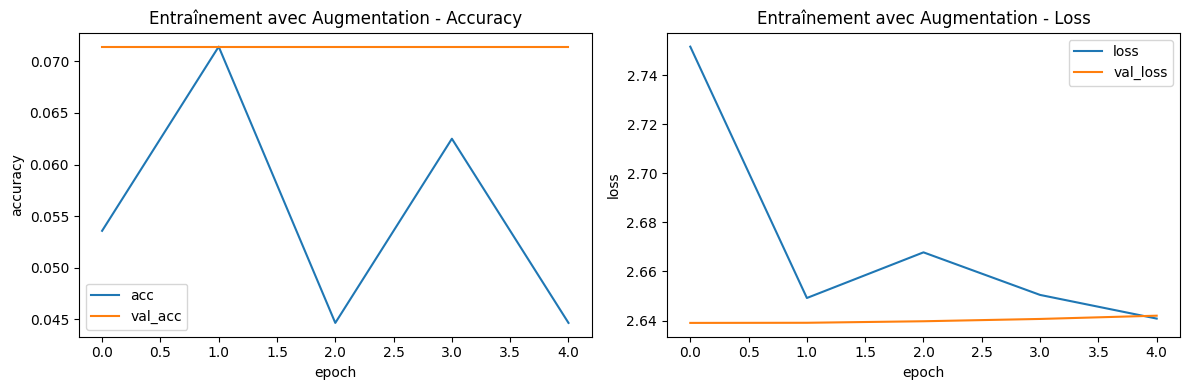

In [58]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

flow_train = datagen.flow_from_directory(str(base), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
                                        class_mode='sparse', subset='training', seed=SEED)
flow_val = datagen.flow_from_directory(str(base), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
                                      class_mode='sparse', subset='validation', seed=SEED)

model_aug = build_variant(num_classes)
hist_aug = model_aug.fit(flow_train, validation_data=flow_val, epochs=5, verbose=2)
plot_curves(hist_aug, title='Entraînement avec Augmentation')

**Learning point**  
Augmentation encodes invariances like rotation and translation. It increases effective sample diversity which often reduces overfitting.


## Part 5. Performance evaluation and analysis

**As stated in the exercises**  
Plot training and validation curves. Compute precision, recall, F1, and a confusion matrix. Visualize predictions on a test set and analyze misclassifications.


In [56]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def collect_preds(model, ds):
    y_true = []
    y_prob = []
    for xb, yb in ds:
        pr = model.predict(xb, verbose=0)
        y_prob.append(pr)
        y_true.append(yb.numpy())
    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    y_pred = np.argmax(y_prob, axis=1)
    return y_true, y_pred, y_prob

def plot_confusion(cm, labels):
    import seaborn as sns
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

Generating Final Classification Report...
              precision    recall  f1-score   support

    flower_0      0.000     0.000     0.000         2
    flower_1      0.000     0.000     0.000         1
   flower_10      0.000     0.000     0.000         4
   flower_11      0.000     0.000     0.000         2
   flower_12      0.000     0.000     0.000         0
   flower_13      0.000     0.000     0.000         2
    flower_2      0.036     1.000     0.069         1
    flower_3      0.000     0.000     0.000         3
    flower_4      0.000     0.000     0.000         1
    flower_5      0.000     0.000     0.000         2
    flower_6      0.000     0.000     0.000         4
    flower_7      0.000     0.000     0.000         1
    flower_8      0.000     0.000     0.000         2
    flower_9      0.000     0.000     0.000         3

    accuracy                          0.036        28
   macro avg      0.003     0.071     0.005        28
weighted avg      0.001     0.036     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

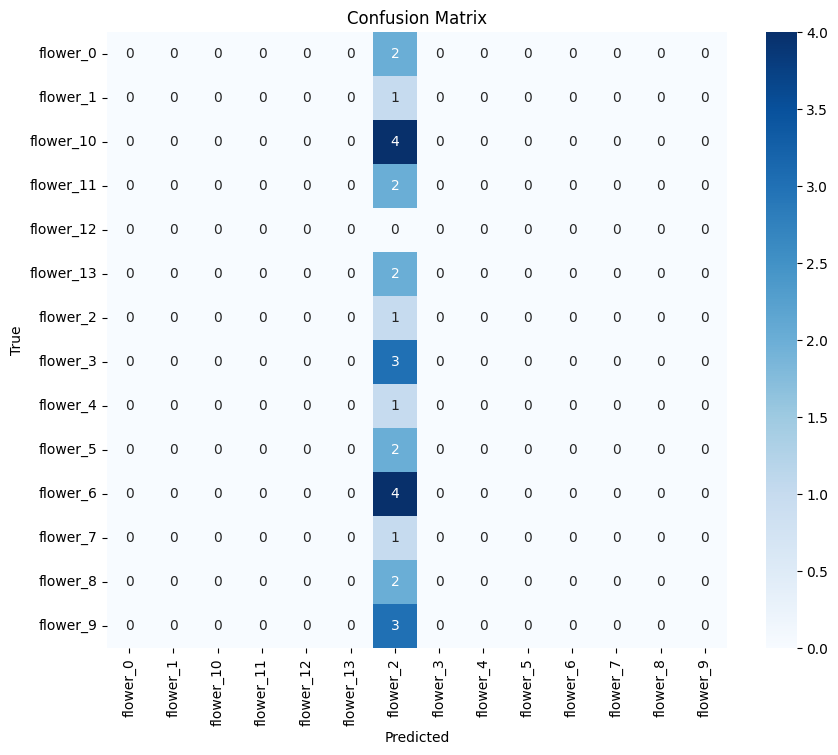

In [60]:
# Final Evaluation using the augmented model
print("Generating Final Classification Report...")
y_true, y_pred, y_prob = collect_preds(model_aug, val_ds)

# Define all possible labels to avoid mismatch errors if some classes are missing in the validation set
import numpy as np
all_labels = np.arange(len(class_names))

print(classification_report(y_true, y_pred, labels=all_labels, target_names=class_names, digits=3))

cm = confusion_matrix(y_true, y_pred, labels=all_labels)
plot_confusion(cm, class_names)

In [ ]:
# To-Do: visualize a few predictions and inspect errors
# import random
# take = 12
# imgs, labels = next(iter(val_ds.unbatch().batch(take)))
# probs = best_model.predict(imgs, verbose=0)
# preds = probs.argmax(axis=1)
# for i in range(take):
#     plt.figure(figsize=(2.5,2.5))
#     plt.imshow(imgs[i].numpy().astype('uint8'))
#     t = f"true: {class_names[int(labels[i])]}\npred: {class_names[int(preds[i])]}"
#     plt.title(t)
#     plt.axis("off")
#     plt.tight_layout()
#     plt.show()

**To-Do (written):** Identify classes that your model finds difficult. Explain possible causes such as similar morphology or color, or small sample counts.


## Part 6. Model saving and deployment (optional)

**As stated in the exercises**  
Save your trained model in `.h5` or SavedModel format. Optionally consider web or cloud deployment.


In [54]:
# Sauvegarde du modèle final
os.makedirs("./models", exist_ok=True)
best_model.save("./models/flower_cnn_final.h5")
print("Modèle sauvegardé dans ./models/flower_cnn_final.h5")

Modèle sauvegardé dans ./models/flower_cnn_final.h5
